# Decaying barotropic QG beta-plane turbulence


An example of decaying barotropic quasi-geostrophic turbulence on a beta plane.

## Install dependencies

First let's make sure we have all required packages installed.

```julia
using Pkg
pkg"add GeophysicalFlows, CairoMakie, Printf, Statistics, Random"
```

## Let's begin
Let's load `GeophysicalFlows.jl` and some other packages we need.

In [1]:
using GeophysicalFlows, CairoMakie, Printf, Random

using Statistics: mean

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical parameters and time-stepping parameters

In [3]:
      n = 128            # 2D resolution: n² grid points
stepper = "FilteredRK4"  # timestepper
     dt = 0.04           # timestep
 nsteps = 2000           # total number of time-steps
 nsubs  = 20             # number of time-steps for intermediate logging/plotting (nsteps must be multiple of nsubs)
nothing # hide

## Physical parameters

In [4]:
L = 2π        # domain size
β = 10.0      # planetary PV gradient
μ = 0.0       # bottom drag
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments.
We use `stepper = "FilteredRK4"`. Filtered timesteppers apply a wavenumber-filter
at every time-step that removes enstrophy at high wavenumbers and, thereby,
stabilize the problem, despite that we use the default viscosity coefficient `ν=0`.
Thus, we choose not to do any dealiasing by providing `aliased_fraction=0`.

In [5]:
prob = SingleLayerQG.Problem(dev; nx=n, Lx=L, β, μ, dt, stepper, aliased_fraction=0)
nothing # hide

and define some shortcuts

In [6]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid
x, y = grid.x, grid.y
nothing # hide

## Setting initial conditions

Our initial condition consist of a flow that has power only at wavenumbers with
$6 < \frac{L}{2\pi} \sqrt{k_x^2 + k_y^2} < 10$ and initial energy $E_0$.
`device_array()` function returns the array type appropriate for the device, i.e., `Array` for
`dev = CPU()` and `CuArray` for `dev = GPU()`.

In [7]:
E₀ = 0.08 # energy of initial condition

K = @. sqrt(grid.Krsq)                          # a 2D array with the total wavenumber

Random.seed!(1234)
q₀h = device_array(dev)(randn(Complex{eltype(grid)}, size(sol)))
@. q₀h = ifelse(K < 6  * 2π/L, 0, q₀h)
@. q₀h = ifelse(K > 10 * 2π/L, 0, q₀h)
@. q₀h[1, :] = 0    # remove any power from zonal wavenumber k=0
q₀h *= sqrt(E₀ / SingleLayerQG.energy(q₀h, vars, params, grid)) # normalize q₀ to have energy E₀
q₀ = irfft(q₀h, grid.nx)

SingleLayerQG.set_q!(prob, q₀)
nothing # hide

Let's plot the initial vorticity and streamfunction. Note that when plotting, we decorate
the variable to be plotted with `Array()` to make sure it is brought back on the CPU when
`vars` live on the GPU.

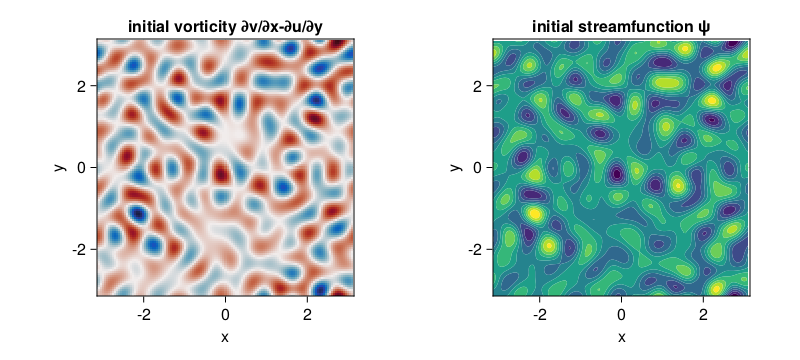

In [8]:
fig = Figure(resolution = (800, 360))

axq = Axis(fig[1, 1];
           xlabel = "x",
           ylabel = "y",
           title = "initial vorticity ∂v/∂x-∂u/∂y",
           aspect = 1,
           limits = ((-grid.Lx/2, grid.Lx/2), (-grid.Ly/2, grid.Ly/2))
           )

axψ = Axis(fig[1, 2];
           xlabel = "x",
           ylabel = "y",
           title = "initial streamfunction ψ",
           aspect = 1,
           limits = ((-grid.Lx/2, grid.Lx/2), (-grid.Ly/2, grid.Ly/2))
           )

heatmap!(axq, x, y, Array(vars.q); colormap = :balance)

contourf!(axψ, x, y, Array(vars.ψ); colormap = :viridis)

fig

## Diagnostics

Create Diagnostics -- `energy` and `enstrophy` functions are imported at the top.

In [9]:
E = Diagnostic(SingleLayerQG.energy, prob; nsteps)
Z = Diagnostic(SingleLayerQG.enstrophy, prob; nsteps)
diags = [E, Z] # A list of Diagnostics types passed to "stepforward!" will  be updated every timestep.
nothing # hide

## Output

We choose folder for outputing `.jld2` files and snapshots (`.png` files).

In [10]:
filepath = "."
plotpath = "./plots_decayingbetaturb"
plotname = "snapshots"
filename = joinpath(filepath, "decayingbetaturb.jld2")
nothing # hide

Do some basic file management,

In [11]:
if isfile(filename); rm(filename); end
if !isdir(plotpath); mkdir(plotpath); end
nothing # hide

and then create Output.

In [12]:
get_sol(prob) = prob.sol # extracts the Fourier-transformed solution
out = Output(prob, filename, (:sol, get_sol))
nothing # hide

## Visualizing the simulation

We plot the vorticity and streamfunction and their corresponding zonal mean structure.

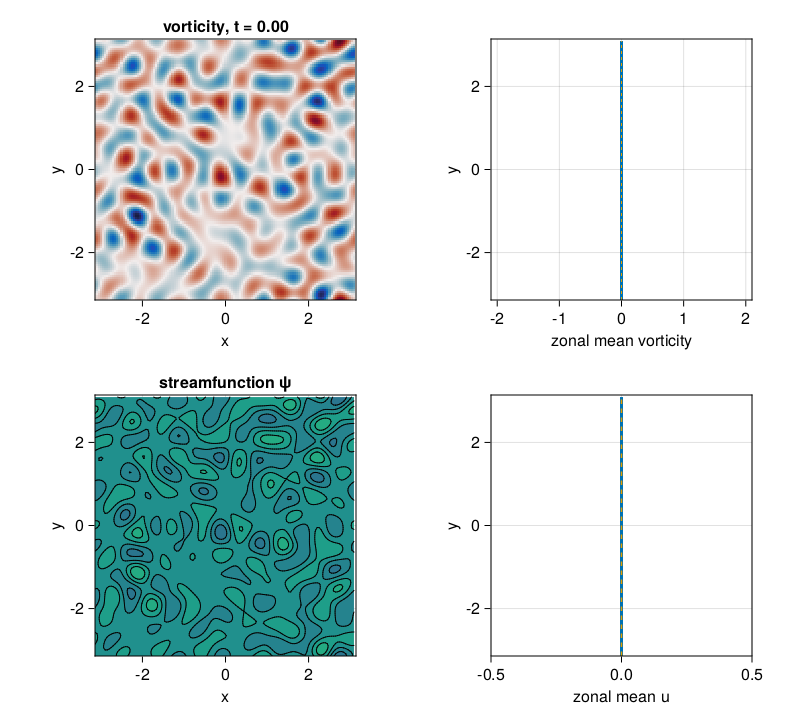

In [13]:
Lx, Ly = grid.Lx, grid.Ly

title_q = Observable(@sprintf("vorticity, t = %.2f", clock.t))
title_ψ = "streamfunction ψ"

fig = Figure(resolution=(800, 720))

axis_kwargs = (xlabel = "x",
               ylabel = "y",
               aspect = 1,
               limits = ((-Lx/2, Lx/2), (-Ly/2, Ly/2)))

axq = Axis(fig[1, 1]; title = title_q, axis_kwargs...)

axψ = Axis(fig[2, 1]; title = title_ψ, axis_kwargs...)

axq̄ = Axis(fig[1, 2],
           xlabel = "zonal mean vorticity",
           ylabel = "y",
           aspect = 1,
           limits = ((-2.1, 2.1), (-Ly/2, Ly/2)))

axū = Axis(fig[2, 2],
           xlabel = "zonal mean u",
           ylabel = "y",
           aspect = 1,
           limits = ((-0.5, 0.5), (-Ly/2, Ly/2)))

q  = Observable(Array(vars.q))
ψ  = Observable(Array(vars.ψ))
q̄ₘ = Observable(Array(vec(mean(vars.q, dims=1))))
ūₘ = Observable(Array(vec(mean(vars.u, dims=1))))

heatmap!(axq, x, y, q;
         colormap = :balance, colorrange = (-12, 12))

levels = collect(range(-0.7, stop=0.7, length=20))

contourf!(axψ, x, y, ψ;
         levels, colormap = :viridis, colorrange = (-0.35, 0.35))
contour!(axψ, x, y, ψ;
         levels, color = :black)

lines!(axq̄, q̄ₘ, y; linewidth = 3)
lines!(axq̄, 0y, y; linewidth = 1, linestyle = :dash)

lines!(axū, ūₘ, y; linewidth = 3)
lines!(axū, 0y, y; lindewidth = 1, linestyle = :dash)

fig

## Time-stepping the `Problem` forward

We step the `Problem` forward in time.

In [14]:
startwalltime = time()

frames = 0:round(Int, nsteps / nsubs)

record(fig, "singlelayerqg_betadecay.mp4", frames, framerate = 8) do j
  if j % round(Int, nsteps/nsubs / 4) == 0
    cfl = clock.dt * maximum([maximum(vars.u) / grid.dx, maximum(vars.v) / grid.dy])

    log = @sprintf("step: %04d, t: %d, cfl: %.2f, E: %.4f, Q: %.4f, walltime: %.2f min",
      clock.step, clock.t, cfl, E.data[E.i], Z.data[Z.i], (time()-startwalltime)/60)

    println(log)
  end

  q[] = vars.q
  ψ[] = vars.ψ
  q̄ₘ[] = vec(mean(vars.q, dims=1))
  ūₘ[] = vec(mean(vars.u, dims=1))

  title_q[] = @sprintf("vorticity, t = %.2f", clock.t)

  stepforward!(prob, diags, nsubs)
  SingleLayerQG.updatevars!(prob)
end
nothing # hide

step: 0000, t: 0, cfl: 0.86, E: 0.0800, Q: 5.0860, walltime: 0.00 min
step: 0500, t: 20, cfl: 0.87, E: 0.0786, Q: 1.8862, walltime: 0.16 min
step: 1000, t: 40, cfl: 0.71, E: 0.0784, Q: 1.2623, walltime: 0.27 min
step: 1500, t: 60, cfl: 0.87, E: 0.0783, Q: 1.1067, walltime: 0.39 min
step: 2000, t: 80, cfl: 0.85, E: 0.0783, Q: 1.0400, walltime: 0.51 min


![](singlelayerqg_betadecay.mp4)

## Save

Finally, we can save, e.g., the last snapshot via
```julia
savename = @sprintf("%s_%09d.png", joinpath(plotpath, plotname), clock.step)
savefig(savename)
```

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*